# CICIoT2023 — DT, RF, XGBoost: quy mô, trọng số và đánh giá 8 lớp
**Nguyễn Ngọc Dương — dữ liệu và mô hình phát hiện. Chạy trên Kaggle.**

Đầu ra: pipeline suy luận tái sử dụng, model/config, bảng precision/recall/F1/support và macro-F1, confusion matrix 8×8, dự đoán có ID, thời gian fit/inference và RAM.

1. Add Input output **processing** `20261007_164739_35f682b9` và **pilot** `pilot_20261008_022915_ea9a88b0` (đầy đủ file, không chỉ plots).
2. Chọn **CPU**, đọc cấu hình rồi **Save Version → Run All**. Không cần Internet nếu các thư viện sẵn có. Không tự nâng cấp thư viện giữa một run.
3. Mặc định: 9 run không trọng số (3 model × 3 budget), 6 run có trọng số tại budget được chọn, chốt một cấu hình cho mỗi thuật toán rồi đánh giá 3 model đó trên test. Có thể mất nhiều giờ tùy CPU; mỗi thí nghiệm được lưu ngay.
4. Muốn dừng ở validation trước khi chốt để còn nghiên cứu SHAP/feature selection, đặt `RUN_FINAL_TEST=False`. Sau khi đã xem test, không dùng test để đổi cấu hình rồi công bố như test chưa từng xem.
5. Kết quả ở `/kaggle/working/model_experiments/<run_id>/`. Khi hết phiên, tải/gắn lại output và đặt `RESUME_FROM` để tiếp tục; không phải huấn luyện lại các run hoàn tất.

Notebook không chạy SHAP-RFECV/SMOTE, không học mô hình nhị phân/34 lớp. SHAP chọn đặc trưng là thí nghiệm tiếp theo; Hải phụ trách XAI. Không tự tick công việc hoàn tất chỉ vì đã tạo notebook.

**Sửa lỗi giao nhau float32 (revision 1.2):** dùng lại input processing/pilot hiện có, đặt `RESUME_FROM=None` và Restart & Run All để tạo run mới. Mask validation được cố định trước train; mask test sau freeze. Không sửa/xóa dữ liệu nguồn hoặc bỏ qua audit.


## Protocol cố định trước khi chạy

- Đủ 44 feature; DT/RF/XGBoost cùng nhánh **raw đã điền thiếu/chọn cột**, chuyển float32 giống nhau trước estimator. Không log/scale thêm. Pipeline xuất ra dùng đúng thứ tự feature.
- Preprocessing đã fit trên toàn train nguồn; pilot là so sánh quy mô huấn luyện classifier với preprocessing cố định. Lưu source run/hash; không tuyên bố mỗi pilot tự fit preprocessing.
- Nguồn validation 862.150 dòng và test 830.443 dòng đã purge ở pipeline trước. Notebook này tiếp tục lọc giao nhau ở raw float32 theo ưu tiên train (hợp mọi budget) → validation → test; số dòng thực dùng và support được lưu trong audit. Cùng một mask validation áp dụng cho mọi model/budget; phân bố đã thay đổi và chưa chứng minh độc lập theo phiên/thiết bị. Các pilot giữ cùng số mẫu BruteForce/Web-Based, nên tăng budget đồng thời thay tỷ lệ lớp.
- Giai đoạn A: không trọng số, seed/cấu hình cây cố định, đủ 3 model ở mỗi budget. Chọn budget nhỏ nhất có macro-F1 trung bình 3 model cách budget tốt nhất không quá **0,005**, recall trung bình cho **từng** lớp BruteForce/Web-Based không giảm quá **0,02**. Đây là ngưỡng vận hành đặt trước, không phải kiểm định thống kê. Báo RAM/time bên cạnh; nếu không chạy đủ thì dừng, không tự bỏ run thất bại để chọn budget.
- Giai đoạn B: tại budget được chọn, so none / inverse-sqrt / balanced; weight tính từ train hiện tại, trung bình trên các mẫu bằng 1. Không cân bằng validation/test. Chọn từng model bằng macro-F1, hòa thì F1 trung bình hai lớp hiếm, rồi thời gian fit. Tất cả precision/recall vẫn được báo để thấy đánh đổi.
- Không early stopping hay tuning sâu trong notebook này: số cây/vòng boosting cố định giúp so budget nhất quán. Kết quả là baseline có chọn budget/weight; không khẳng định đã tối ưu toàn bộ hyperparameter.
- Test chỉ được mở sau khi `frozen_selection.json` đã ghi model/config/hash. Không refit trên validation; đánh giá đúng model đã chọn. Một seed mô hình là giới hạn; bước nghiên cứu độ ổn định có thể chạy riêng trước khi mở test.

In [10]:
import os, sys, gc, json, time, uuid, hashlib, shutil, platform, threading, warnings, subprocess, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, psutil, sklearn, xgboost
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, log_loss
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Chỉ chỉnh trước một run mới. Resume yêu cầu cùng protocol và phiên bản thư viện.
PROCESSED_DIR = "/kaggle/input/notebooks/nguynngcdngb22vt/ciciot2023-do-an-processing/processed_data/20261007_164739_35f682b9"
PILOT_DIR = "/kaggle/input/notebooks/nguynngcdngb22vt/ciciot2023-do-an-pilot/pilot_data/pilot_20261008_022915_ea9a88b0"
RESUME_FROM = None  # đường dẫn run trước, ở /kaggle/input hoặc /kaggle/working
EXPECTED_SOURCE = '20261007_164739_35f682b9'
EXPECTED_PILOT = 'pilot_20261008_022915_ea9a88b0'
BUDGETS = [100_000, 500_000, 1_000_000]
SEED = 42
N_JOBS = min(4, os.cpu_count() or 1)
PREDICT_BATCH = 25_000
BENCHMARK_BATCH = 1024
BENCHMARK_REPEATS = 30
RUN_FINAL_TEST = True  # False nếu còn muốn cải tiến/tuning trước khi xem test.
VERIFY_INPUT_HASHES = True
MACRO_TOLERANCE = 0.005
RARE_RECALL_TOLERANCE = 0.02
CLASS_NAMES = ['Normal','BruteForce','DDoS','DoS','Mirai','Recon','Spoofing','Web-Based']
IDS = np.arange(8)
MODELS = ['DT','RF','XGBoost']
PARAMS = {
 'DT': dict(max_depth=20, min_samples_leaf=2, random_state=SEED),
 'RF': dict(n_estimators=200, max_depth=20, min_samples_leaf=2,
            max_features='sqrt', n_jobs=N_JOBS, random_state=SEED),
 'XGBoost': dict(n_estimators=300, max_depth=6, learning_rate=0.1,
                 min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                 reg_lambda=1.0, objective='multi:softprob', num_class=8,
                 tree_method='hist', device='cpu', max_bin=256,
                 eval_metric='mlogloss', n_jobs=N_JOBS, random_state=SEED),
}
assert Path('/kaggle/input').is_dir() and Path('/kaggle/working').is_dir(), 'Chỉ chạy notebook này trên Kaggle.'
assert int(xgboost.__version__.split('.')[0]) >= 2, 'Cần XGBoost >=2.0; chọn Kaggle image phù hợp rồi chạy lại từ đầu.'
assert BUDGETS == sorted(set(BUDGETS)) and len(BUDGETS) >= 1
assert all(isinstance(n,int) and n>0 for n in BUDGETS)
assert PREDICT_BATCH > 0 and BENCHMARK_BATCH > 0 and BENCHMARK_REPEATS >= 10
assert MACRO_TOLERANCE >= 0 and RARE_RECALL_TOLERANCE >= 0
VERSIONS = {n:importlib.metadata.version(n) for n in ['numpy','pandas','scipy','scikit-learn','xgboost','joblib','psutil','matplotlib']}
VERSIONS['python'] = platform.python_version()
print('Môi trường:', VERSIONS)
print('CPU threads:', N_JOBS, '| RAM GiB:', round(psutil.virtual_memory().total/2**30,2))

Môi trường: {'numpy': '2.1.3', 'pandas': '2.3.3', 'scipy': '1.16.3', 'scikit-learn': '1.6.1', 'xgboost': '3.4.1', 'joblib': '1.6.0', 'psutil': '5.9.5', 'matplotlib': '3.10.0', 'python': '3.13.15'}
CPU threads: 4 | RAM GiB: 31.35


## 1. Định vị nguồn, khóa protocol và chuẩn bị thư mục run
Không dùng đường dẫn Kaggle cũ trong manifest. Nếu nhiều bản cùng run ID được gắn, chỉ rõ `PROCESSED_DIR`/`PILOT_DIR`. Resume kiểm tra hash protocol, dữ liệu và phiên bản; gắn output trước vào Kaggle Input nếu cần.

In [11]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))
def write_json(path, obj):
    path = Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    tmp.write_text(json.dumps(obj, ensure_ascii=False, indent=2, allow_nan=False),encoding='utf-8')
    tmp.replace(path)
def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda:f.read(8*1024*1024),b''): h.update(chunk)
    return h.hexdigest()
def object_hash(obj):
    return hashlib.sha256(json.dumps(obj,sort_keys=True,ensure_ascii=False).encode()).hexdigest()
def now(): return datetime.now(timezone.utc).isoformat()
def safe_file(base, relative):
    p=Path(relative)
    if p.is_absolute() or '..' in p.parts: raise ValueError(f'Unsafe relative path: {p}')
    result=Path(base)/p
    if not result.is_file(): raise FileNotFoundError(result)
    return result

def resolve_run(explicit, filename, key, expected):
    if explicit:
        path=Path(explicit)
        assert read_json(path/filename).get(key)==expected, f'Wrong run: {path}'
        return path
    candidates=[]
    for root in [Path('/kaggle/input'),Path('/kaggle/working/processed_data'),Path('/kaggle/working/pilot_data')]:
        if not root.exists(): continue
        for p in root.rglob(filename):
            if any(part in p.parts for part in ['source_reference','source_snapshot','handoff']): continue
            if filename=='pilot_manifest.json' and p.parent.name.startswith('train_'): continue
            try:
                if read_json(p).get(key)==expected: candidates.append(p.parent.resolve())
            except (OSError,ValueError): pass
    candidates=sorted(set(candidates))
    if len(candidates)!=1: raise ValueError(f'Cần chỉ rõ đường dẫn {filename}; candidates={candidates}')
    return candidates[0]

SOURCE=resolve_run(PROCESSED_DIR,'preprocessing_config.json','run_id',EXPECTED_SOURCE)
PILOT=resolve_run(PILOT_DIR,'pilot_manifest.json','pilot_run_id',EXPECTED_PILOT)
SOURCE_CONFIG=read_json(SOURCE/'preprocessing_config.json')
PILOT_CONFIG=read_json(PILOT/'pilot_manifest.json')
SCHEMA=read_json(SOURCE/'feature_schema.json')
FEATURES=SOURCE_CONFIG['final_features']
assert read_json(SOURCE/'run_status.json')['status']=='complete'
assert read_json(PILOT/'run_status.json')['status']=='complete'
assert PILOT_CONFIG['source_processing_run_id']==EXPECTED_SOURCE
assert PILOT_CONFIG['feature_names']==FEATURES==SCHEMA['output_features']
assert SOURCE_CONFIG['class_names']==PILOT_CONFIG['class_names']==CLASS_NAMES
assert SOURCE_CONFIG['class_mapping']==PILOT_CONFIG['class_to_id']==dict(zip(CLASS_NAMES,range(8)))
assert len(FEATURES)==44 and len(set(FEATURES))==44
assert sha256(SOURCE/'preprocessing_config.json')==PILOT_CONFIG['source_config_sha256']
assert set(BUDGETS).issubset(PILOT_CONFIG['budgets'])
PROTOCOL = dict(source_run=EXPECTED_SOURCE,pilot_run=EXPECTED_PILOT,
    source_config_sha256=sha256(SOURCE/'preprocessing_config.json'),
    pilot_manifest_sha256=sha256(PILOT/'pilot_manifest.json'),
    budgets=BUDGETS,seed=SEED,models=MODELS,params=PARAMS,feature_names=FEATURES,
    class_names=CLASS_NAMES,versions=VERSIONS,input_view='raw cast float32 for all estimators',
    preprocessing_fit_scope='full source train; reused without refit',
    macro_tolerance=MACRO_TOLERANCE,rare_recall_tolerance=RARE_RECALL_TOLERANCE,
    weight_modes=['none','sqrt','balanced'],evaluation='same fixed float32-purged validation for all models/budgets; test purged after frozen selection',
    predict_batch=PREDICT_BATCH,benchmark_batch=BENCHMARK_BATCH,
    benchmark_repeats=BENCHMARK_REPEATS,verify_input_hashes=VERIFY_INPUT_HASHES,
    notebook_revision='1.2',float32_overlap_policy='purge_eval train union of all budgets -> validation -> test; BLAKE2b-128 canonical float32; masks saved')
PROTOCOL_HASH=object_hash(PROTOCOL)
ROOT=Path('/kaggle/working/model_experiments');ROOT.mkdir(exist_ok=True)
if RESUME_FROM:
    previous=Path(RESUME_FROM)
    assert read_json(previous/'protocol.json')==PROTOCOL, 'Resume khác protocol/version: tạo run mới thay vì trộn kết quả.'
    OUT=ROOT/previous.name
    if previous.resolve()!=OUT.resolve():
        assert not OUT.exists(), 'Thư mục đích resume đã tồn tại; đặt RESUME_FROM trỏ vào thư mục working đó.'
        shutil.copytree(previous,OUT)
else:
    OUT=ROOT/f'models_{datetime.now(timezone.utc):%Y%m%d_%H%M%S}_{uuid.uuid4().hex[:8]}'
    OUT.mkdir(exist_ok=False)
    write_json(OUT/'protocol.json',PROTOCOL)
    write_json(OUT/'run_status.json',dict(status='in_progress',started_at=now(),protocol_hash=PROTOCOL_HASH))
RUN_ID=OUT.name
(OUT/'source_snapshot').mkdir(exist_ok=True)
for name in ['preprocessing_config.json','feature_schema.json','label_mapping.json','source_manifest.json','class_support_final.csv']:
    shutil.copy2(SOURCE/name,OUT/'source_snapshot'/name)
shutil.copy2(PILOT/'pilot_manifest.json',OUT/'source_snapshot'/'pilot_manifest.json')
shutil.copy2(PILOT/'class_distribution_all_budgets.csv',OUT/'source_snapshot'/'pilot_class_distribution.csv')
write_json(OUT/'environment.json',dict(versions=VERSIONS,platform=platform.platform(),processor=platform.processor(),
    logical_cpu=os.cpu_count(),ram_bytes=psutil.virtual_memory().total,threads=N_JOBS,device='CPU',
    source_path=str(SOURCE),pilot_path=str(PILOT),resume_from=RESUME_FROM))
(OUT/'requirements_runtime.txt').write_text('\n'.join(f'{k}=={v}' for k,v in VERSIONS.items() if k!='python')+'\n')
print('Source:',SOURCE,'\nPilot:',PILOT,'\nOutput:',OUT)


Source: /kaggle/input/notebooks/nguynngcdngb22vt/ciciot2023-do-an-processing/processed_data/20261007_164739_35f682b9 
Pilot: /kaggle/input/notebooks/nguynngcdngb22vt/ciciot2023-do-an-pilot/pilot_data/pilot_20261008_022915_ea9a88b0 
Output: /kaggle/working/model_experiments/models_20261008_073827_d29a37c3


## 2. Kiểm tra dữ liệu train/validation, chưa mở test
Đọc NPY bằng memory map, hash train theo manifest, kiểm tra đủ lớp và index. Lọc khỏi evaluation các vector raw float32 đã có ở split ưu tiên trước; giữ train nguyên vẹn, không dựa vào nhãn hoặc kết quả mô hình để chọn dòng. Lưu index và số mẫu trước/sau cho đủ 8 lớp. Không sao chép lại toàn bộ ma trận evaluation vào RAM; chỉ lấy các batch theo index. Metadata pickle chỉ nạp từ output processing/pilot do chính bạn tạo. Không nạp transformer pickle khác phiên bản: pipeline suy luận cuối sẽ tái dựng phép điền median cố định từ JSON nguồn bằng thư viện hiện tại, không học lại thống kê.
Kiểm tra thêm giao nhau ở **raw float32**, vì ma trận raw cũ lưu float64 còn các cây dùng float32. Nếu phát hiện giao nhau, notebook lọc theo quy tắc đã công bố và lưu audit/mask; chỉ dừng nếu một lớp không còn mẫu hoặc kiểm tra sau lọc không đạt. Phần kiểm tra test chỉ thực hiện sau đóng băng.


In [12]:
INPUT_AUDIT=[]
def checked_array(path,shape=None,dtype=None):
    a=np.load(path,mmap_mode='r',allow_pickle=False)
    if shape is not None: assert list(a.shape)==list(shape),(path,a.shape,shape)
    if dtype is not None: assert str(a.dtype)==dtype,(path,a.dtype,dtype)
    assert Path(path).stat().st_size==a.offset+a.nbytes, f'File truncated/extra bytes: {path}'
    return a

def validate_xy(X,y,support):
    assert X.ndim==2 and X.shape[1]==len(FEATURES) and y.shape==(len(X),)
    assert np.issubdtype(y.dtype,np.integer) and int(y.min())>=0 and int(y.max())<8
    counts=np.bincount(y,minlength=8)
    assert np.all(counts>0)
    assert counts.tolist()==[support[c] for c in CLASS_NAMES]
    for i in range(0,len(X),PREDICT_BATCH):
        with np.errstate(over='ignore',invalid='ignore'):
            part=np.asarray(X[i:i+PREDICT_BATCH],dtype=np.float32)
        assert np.isfinite(part).all(),f'NaN/Inf hoặc tràn float32 ở {i}'
    return counts

SOURCE_Y=checked_array(SOURCE/'y_train.npy',[PILOT_CONFIG['source_train_rows']])
assert sha256(SOURCE/'y_train.npy')==PILOT_CONFIG['source_y_train_sha256']
PILOTS={};previous_indices=None
for budget in BUDGETS:
    info=next(x for x in PILOT_CONFIG['pilots'] if x['budget']==budget)
    folder=PILOT/info['directory'];manifest=read_json(PILOT/info['manifest'])
    assert manifest['status']=='complete' and manifest['features_exported']
    assert manifest['feature_names']==FEATURES and manifest['class_names']==CLASS_NAMES
    xinfo=manifest['features']['raw']
    paths={xinfo['file']:xinfo['sha256'],**manifest['checksums_sha256']}
    for name,digest in paths.items():
        path=safe_file(folder,name)
        actual=sha256(path) if VERIFY_INPUT_HASHES else None
        if actual is not None: assert actual==digest,f'Checksum mismatch: {path}'
        INPUT_AUDIT.append(dict(file=str(path),bytes=path.stat().st_size,expected_sha256=digest,actual_sha256=actual))
    X=checked_array(folder/xinfo['file'],[budget,44],'float64')
    y=checked_array(folder/manifest['target_file'],[budget])
    validate_xy(X,y,manifest['class_support'])
    idx=checked_array(folder/manifest['indices_file'],[budget])
    assert np.issubdtype(idx.dtype,np.integer) and np.all(idx[1:]>idx[:-1])
    assert idx[0]>=0 and idx[-1]<PILOT_CONFIG['source_train_rows']
    assert np.array_equal(y,SOURCE_Y[idx]), 'Pilot target does not match source index'
    if previous_indices is not None:
        pos=np.searchsorted(idx,previous_indices)
        assert np.all(pos<len(idx)) and np.array_equal(idx[pos],previous_indices)
    previous_indices=idx
    for rare in ['BruteForce','Web-Based']:
        assert manifest['class_support'][rare]==PILOT_CONFIG['source_train_support'][rare]
    PILOTS[budget]=(folder,manifest)
    del X,y

# Validation metadata is checked against y, then only the row IDs are kept.
def open_evaluation(split):
    if split=='test':
        assert (OUT/'frozen_selection.json').is_file(), 'Phải đóng băng model trước khi đọc test.'
    a=SOURCE_CONFIG['artifacts'][split]
    X=checked_array(safe_file(SOURCE,a['raw_file']),a['shape'],a['raw_dtype'])
    y=checked_array(safe_file(SOURCE,a['target_file']),[a['shape'][0]])
    validate_xy(X,y,a['class_support'])
    meta=pd.read_pickle(safe_file(SOURCE,a['metadata_file']))
    assert len(meta)==len(y) and np.array_equal(meta['class_id'].to_numpy(),y)
    row_ids=meta['source_row_index'].to_numpy(dtype=np.int64,copy=True)
    assert len(np.unique(row_ids))==len(row_ids) and np.all(row_ids>=0)
    del meta
    audit=dict(split=split,shape=list(X.shape),support=a['class_support'],
               raw_sha256=sha256(SOURCE/a['raw_file']),target_sha256=sha256(SOURCE/a['target_file']),
               metadata_sha256=sha256(SOURCE/a['metadata_file']))
    audit_file=OUT/f'{split}_input_audit.json'
    if audit_file.exists(): assert read_json(audit_file)==audit,'Evaluation input changed during resume.'
    else: write_json(audit_file,audit)
    return X,y,row_ids
XVAL,YVAL,VAL_IDS=open_evaluation('val')
write_json(OUT/'input_integrity.json',INPUT_AUDIT)
# Trees use float32 internally; float64 source vectors can collapse into identical inputs.
class IndexedRows:
    """Read-only row view over a source memmap; select only each requested batch."""
    def __init__(self, source, indices):
        self.source=source
        self.indices=np.asarray(indices,dtype=np.int64)
        self.shape=(len(self.indices),source.shape[1])
        self.ndim=source.ndim
        self.dtype=source.dtype
    def __len__(self): return len(self.indices)
    def __getitem__(self, key):
        if isinstance(key,tuple):
            rows,columns=key
            return self.source[self.indices[rows],columns]
        return self.source[self.indices[key]]

def float32_row_hashes(X):
    hashes=np.empty(len(X),dtype='V16')
    for start in range(0,len(X),PREDICT_BATCH):
        block=np.array(X[start:start+PREDICT_BATCH],dtype='<f4',order='C',copy=True)
        assert np.isfinite(block).all()
        block[block==0]=0
        hashes[start:start+len(block)]=np.frombuffer(
            b''.join(hashlib.blake2b(row.tobytes(),digest_size=16).digest() for row in block),dtype='V16')
    return hashes

def float32_hashes(X): return np.unique(float32_row_hashes(X))

def support_counts(y):
    counts=np.bincount(y,minlength=8)
    return {c:int(counts[i]) for i,c in enumerate(CLASS_NAMES)}

EVALUATION_INDICES={}
def purge_evaluation(split,X,y,source_row_ids,train_hashes,validation_hashes=None):
    hashes=float32_row_hashes(X)
    train_hit=np.isin(hashes,train_hashes)
    val_hit=np.zeros(len(y),dtype=bool)
    if validation_hashes is not None:
        val_hit=(~train_hit)&np.isin(hashes,validation_hashes)
    keep=~(train_hit|val_hit)
    indices=np.flatnonzero(keep).astype(np.int64)
    retained_y=np.asarray(y[indices])
    retained_ids=source_row_ids[indices]
    retained_hashes=np.unique(hashes[keep])
    report=dict(split=split,protocol_hash=PROTOCOL_HASH,
        hash='BLAKE2b-128',representation='44 raw float32 features; zero sign canonicalized',
        priority=['train_union_of_all_budgets','validation','test'],
        train_union_budget=max(BUDGETS),label_independent=True,within_eval_duplicates='retained',
        before_rows=len(y),after_rows=len(indices),removed_rows=int((~keep).sum()),
        removed_percent=float((~keep).mean()*100),
        removed_for_train_overlap=int(train_hit.sum()),removed_for_validation_overlap=int(val_hit.sum()),
        before_class_support=support_counts(y),after_class_support=support_counts(retained_y),
        removed_class_support=support_counts(np.asarray(y[~keep])),
        kept_indices_file=f'{split}_float32_kept_processed_indices.npy',
        row_coordinate_system='zero-based row in original processed split; before this notebook purge',
        limitation='evaluation population changed; not proof of device/session/time independence')
    path=OUT/f'{split}_float32_purge_audit.json'
    index_path=OUT/report['kept_indices_file']
    if index_path.exists():
        assert np.array_equal(np.load(index_path,allow_pickle=False),indices), 'Resume evaluation mask changed.'
    else: np.save(index_path,indices,allow_pickle=False)
    report['kept_indices_sha256']=sha256(index_path)
    if path.exists(): assert read_json(path)==report, 'Resume float32 purge audit changed.'
    else: write_json(path,report)
    print(f'{split}: {len(y):,} -> {len(indices):,} rows; removed {report["removed_rows"]:,} '
          f'({report["removed_percent"]:.2f}%)',flush=True)
    display(pd.DataFrame({'class_name':CLASS_NAMES,
        'before':[report['before_class_support'][c] for c in CLASS_NAMES],
        'after':[report['after_class_support'][c] for c in CLASS_NAMES],
        'removed':[report['removed_class_support'][c] for c in CLASS_NAMES]}))
    assert len(indices)>0, f'{split}: no samples after float32 purge.'
    assert all(report['after_class_support'][c]>0 for c in CLASS_NAMES), (
        f'{split}: a class is lost after float32 purge; inspect saved audit, do not silently train/evaluate.')
    assert np.intersect1d(train_hashes,retained_hashes,assume_unique=True).size==0
    if validation_hashes is not None:
        assert np.intersect1d(validation_hashes,retained_hashes,assume_unique=True).size==0
    EVALUATION_INDICES[split]=indices
    return IndexedRows(X,indices),retained_y,retained_ids,retained_hashes

max_folder,max_manifest=PILOTS[max(BUDGETS)]
max_X=checked_array(max_folder/max_manifest['features']['raw']['file'])
TRAIN_FLOAT32_HASHES=float32_hashes(max_X)  # largest nested pilot covers every fitted row
XVAL,YVAL,VAL_IDS,VAL_FLOAT32_HASHES=purge_evaluation(
    'val',XVAL,YVAL,VAL_IDS,TRAIN_FLOAT32_HASHES)
write_json(OUT/'evaluation_policy.json',dict(protocol_hash=PROTOCOL_HASH,
    representation='raw float32',priority=['train_union_of_all_budgets','val','test'],
    same_validation_for_all_models_and_budgets=True,validation_audit='val_float32_purge_audit.json',
    test_audit='test_float32_purge_audit.json',test_opened_only_after_model_freeze=True,
    original_processing_run=EXPECTED_SOURCE,original_data_files_modified=False))
del max_X,SOURCE_Y;gc.collect()
print('Đã cố định validation sau lọc float32 cho mọi model/budget. Chưa mở test.')


val: 862,150 -> 808,943 rows; removed 53,207 (6.17%)


,class_name,before,after,removed
0,Normal,26174,26174,0
1,BruteForce,277,277,0
2,DDoS,590641,538841,51800
3,DoS,168172,167363,809
4,Mirai,56000,55402,598
5,Recon,8542,8542,0
6,Spoofing,11716,11716,0
7,Web-Based,628,628,0


Đã cố định validation sau lọc float32 cho mọi model/budget. Chưa mở test.


## 3. Hàm huấn luyện, đo lường và đánh giá
RAM là peak RSS **toàn process Python được lấy mẫu mỗi 0,1 giây**, không phải VRAM hoặc bộ nhớ riêng estimator; baseline RSS và phần tăng thêm được lưu. Thời gian fit tách chuyển dữ liệu; `predict_proba_seconds` cộng thời gian gọi dự đoán trên các batch đã chuyển float32, loại I/O ghi kết quả. Benchmark riêng dùng 30 lần sau warm-up, batch 1 và 1024, cùng tập mẫu/seed; phản ánh dữ liệu trong RAM, chưa gồm đọc CSV/XAI.

Metric dùng toàn tập validation/test còn lại sau purge float32, không weighted theo training sample_weight; `zero_division=0`, support và số dự đoán từng lớp được lưu để thấy lớp không được dự đoán. Luôn lưu xác suất đủ 8 cột theo mã 0–7.

In [13]:
class RAMMonitor:
    def __enter__(self):
        self.process=psutil.Process();self.baseline=self.process.memory_info().rss
        self.peak=self.baseline;self.stop=threading.Event()
        def sample():
            while not self.stop.wait(0.1): self.peak=max(self.peak,self.process.memory_info().rss)
        self.thread=threading.Thread(target=sample,daemon=True);self.thread.start();return self
    def __exit__(self,*args):
        self.peak=max(self.peak,self.process.memory_info().rss)
        self.stop.set();self.thread.join()

def model_factory(name):
    return {'DT':DecisionTreeClassifier,'RF':RandomForestClassifier,'XGBoost':XGBClassifier}[name](**PARAMS[name])
def make_weights(y,mode):
    counts=np.bincount(y,minlength=8).astype(float)
    exponent={'none':0.0,'sqrt':0.5,'balanced':1.0}[mode]
    w=(len(y)/(8*counts))**exponent
    w/=np.dot(w,counts)/len(y)
    return (None if mode=='none' else w[y]),dict(zip(CLASS_NAMES,map(float,w)))

def benchmark(model,X):
    records=[]
    for size in sorted(set([1,min(BENCHMARK_BATCH,len(X))])):
        idx=np.random.default_rng(SEED+size).choice(len(X),size=size,replace=False)
        block=np.ascontiguousarray(X[idx],dtype=np.float32)
        for _ in range(3): model.predict_proba(block)
        timings=[]
        for _ in range(BENCHMARK_REPEATS):
            start=time.perf_counter();model.predict_proba(block);timings.append(time.perf_counter()-start)
        med=float(np.median(timings));p95=float(np.percentile(timings,95))
        records.append(dict(batch_size=size,repeats=BENCHMARK_REPEATS,warmup=3,
            median_batch_ms=med*1000,p95_batch_ms=p95*1000,
            amortized_ms_per_sample=med*1000/size,throughput_samples_per_second=size/med,
            times_seconds=timings,scope='predict_proba only; CPU; warm in-memory input'))
    return records

def evaluate(model,X,y,row_ids,dest,split):
    dest=Path(dest);dest.mkdir(parents=True,exist_ok=True)
    assert np.array_equal(model.classes_,IDS)
    proba=np.lib.format.open_memmap(dest/'probabilities.npy',mode='w+',dtype='float32',shape=(len(y),8))
    predicted=np.empty(len(y),dtype=np.uint8);predict_seconds=0.0;conversion_seconds=0.0
    for i in range(0,len(y),PREDICT_BATCH):
        end=min(i+PREDICT_BATCH,len(y));t=time.perf_counter()
        block=np.ascontiguousarray(X[i:end],dtype=np.float32);conversion_seconds+=time.perf_counter()-t
        t=time.perf_counter();p=model.predict_proba(block);predict_seconds+=time.perf_counter()-t
        assert p.shape==(end-i,8) and np.isfinite(p).all() and np.all(p>=0) and np.all(p<=1)
        assert np.allclose(p.sum(axis=1),1,atol=1e-5)
        proba[i:end]=p;predicted[i:end]=np.argmax(p,axis=1)
    proba.flush()
    report=classification_report(y,predicted,labels=IDS,target_names=CLASS_NAMES,output_dict=True,zero_division=0)
    cm=confusion_matrix(y,predicted,labels=IDS)
    rows=[dict(class_id=i,class_name=c,**report[c],predicted_count=int((predicted==i).sum())) for i,c in enumerate(CLASS_NAMES)]
    pd.DataFrame(rows).to_csv(dest/'per_class_metrics.csv',index=False)
    pd.DataFrame(cm,index=CLASS_NAMES,columns=CLASS_NAMES).to_csv(dest/'confusion_matrix_counts.csv',index_label='true_class')
    normalized=cm/np.maximum(cm.sum(axis=1,keepdims=True),1)
    pd.DataFrame(normalized,index=CLASS_NAMES,columns=CLASS_NAMES).to_csv(dest/'confusion_matrix_normalized.csv',index_label='true_class')
    
    # ------------------ Visualize Ma trận nhầm lẫn chuẩn format ------------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), dpi=140)
    colormaps = ['Blues', 'Blues']
    titles = ['Phân bố số lượng mẫu (Sample Counts)', 'Tỷ lệ chuẩn hóa theo lớp thực tế (Normalized Recall)']
    
    for idx, (ax, values, title, cmap) in enumerate(zip(axes, [cm, normalized], titles, colormaps)):
        im = ax.imshow(values, interpolation='nearest', cmap=cmap)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=9)
        cbar.outline.set_visible(False)
        
        ax.set_xticks(range(8))
        ax.set_yticks(range(8))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9.5, fontweight='medium')
        ax.set_yticklabels(CLASS_NAMES, fontsize=9.5, fontweight='medium')
        ax.set_xlabel('Nhãn dự đoán (Predicted Label)', fontsize=10.5, fontweight='bold', labelpad=8)
        ax.set_ylabel('Nhãn thực tế (True Label)', fontsize=10.5, fontweight='bold', labelpad=8)
        ax.set_title(title, fontsize=12, fontweight='bold', pad=12, color='#1A252C')
        
        # Thêm lưới viền ô màu trắng mảnh
        ax.set_xticks(np.arange(8) - 0.5, minor=True)
        ax.set_yticks(np.arange(8) - 0.5, minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
        ax.tick_params(which='minor', bottom=False, left=False)
        
        # Viết giá trị vào từng ô
        thresh = values.max() / 2.0 if values.max() > 0 else 1.0
        for r in range(8):
            for c in range(8):
                val = values[r, c]
                if idx == 0:
                    text_str = f"{int(val):,}" if val > 0 else "0"
                else:
                    text_str = f"{val*100:.1f}%" if val > 0 else "0%"
                
                if val == 0:
                    text_color = "#999999"
                elif val > thresh:
                    text_color = "white"
                else:
                    text_color = "#111111"
                    
                ax.text(c, r, text_str, ha="center", va="center", fontsize=8.5,
                        fontweight="bold" if r == c else "normal", color=text_color)
                        
    split_label = "VALIDATION" if split.lower().startswith('val') else "TEST"
    fig.suptitle(
        f"CICIoT2023 — Đánh giá phân loại 8 lớp trên tập {split_label}\nMô hình: {dest.parent.name}",
        fontsize=13.5, fontweight="bold", y=0.98, color="#111111"
    )
    fig.tight_layout(rect=[0, 0.03, 1, 0.94])
    fig.savefig(dest / 'confusion_matrix.png', dpi=160, bbox_inches='tight')
    plt.close(fig)
    pd.DataFrame(dict(evaluation_row_index=np.arange(len(y)),processed_row_index=EVALUATION_INDICES[split],source_row_index=row_ids,
        source_split=split,true_class_id=np.asarray(y),predicted_class_id=predicted)).to_csv(dest/'predictions.csv.gz',index=False,compression='gzip')
    np.save(dest/'predicted_labels.npy',predicted,allow_pickle=False)
    scores=dict(split=split,rows=len(y),macro_precision=float(report['macro avg']['precision']),
        macro_recall=float(report['macro avg']['recall']),macro_f1=float(report['macro avg']['f1-score']),
        weighted_f1=float(report['weighted avg']['f1-score']),accuracy=float(accuracy_score(y,predicted)),
        log_loss=float(log_loss(y,proba,labels=IDS)),rare_mean_f1=float(np.mean([report[c]['f1-score'] for c in ['BruteForce','Web-Based']])),
        recall_BruteForce=float(report['BruteForce']['recall']),recall_Web_Based=float(report['Web-Based']['recall']),
        predict_proba_seconds=predict_seconds,input_conversion_seconds=conversion_seconds,
        zero_division=0,class_order=CLASS_NAMES,probability_rows='same order as predictions.csv.gz')
    write_json(dest/'metrics.json',scores);write_json(dest/'classification_report.json',report)
    write_json(dest/'inference_benchmark.json',benchmark(model,X))
    del proba;return scores

RESULTS={}
def run_experiment(name,budget,mode):
    key=f'{name}_n{budget}_{mode}_s{SEED}'
    dest=OUT/'experiments'/key;complete=dest/'result.json'
    if complete.exists():
        result=read_json(complete)
        assert result['protocol_hash']==PROTOCOL_HASH and result['status']=='complete'
        for rel,digest in result['artifact_hashes'].items():
            assert sha256(safe_file(dest,rel))==digest,f'Cached artifact changed: {rel}'
        RESULTS[key]=result;print('Resume:',key,flush=True);return result
    assert not (OUT/'frozen_selection.json').exists(), 'Run đã đóng băng: không được fit thêm/chọn lại.'
    assert not (OUT/'test_started.json').exists(), 'Test đã được mở: không huấn luyện lại run này.'
    dest.mkdir(parents=True,exist_ok=True)
    write_json(dest/'status.json',dict(status='in_progress',started_at=now(),protocol_hash=PROTOCOL_HASH))
    print('Training:',key,flush=True)
    try:
        folder,manifest=PILOTS[budget];t=time.perf_counter()
        X=np.ascontiguousarray(np.load(folder/manifest['features']['raw']['file'],mmap_mode='r'),dtype=np.float32)
        y=np.load(folder/manifest['target_file'],allow_pickle=False)
        loading_seconds=time.perf_counter()-t
        weights,class_weights=make_weights(y,mode);model=model_factory(name)
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            with RAMMonitor() as mem:
                t=time.perf_counter();model.fit(X,y,sample_weight=weights);fit_seconds=time.perf_counter()-t
        warning_messages=[str(w.message) for w in captured]
        if warning_messages: print('Warnings:',warning_messages,flush=True)
        assert np.array_equal(model.classes_,IDS)
        config=dict(experiment_id=key,model=name,budget=budget,weight_mode=mode,class_weights=class_weights,
            model_params=PARAMS[name],seed=SEED,features=FEATURES,class_order=CLASS_NAMES,
            input_dtype='float32',input_view='raw',protocol_hash=PROTOCOL_HASH,
            source_run=EXPECTED_SOURCE,pilot_run=EXPECTED_PILOT,train_manifest_sha256=sha256(folder/'pilot_manifest.json'))
        write_json(dest/'config.json',config)
        # Fixed validation samples for persistence verification; selection independent of model prediction.
        golden_idx=np.concatenate([np.flatnonzero(YVAL==i)[:2] for i in IDS])
        golden_X=np.ascontiguousarray(XVAL[golden_idx],dtype=np.float32)
        before=model.predict_proba(golden_X)
        joblib.dump(model,dest/'model.joblib',compress=3)
        if name=='XGBoost': model.save_model(dest/'model.ubj')
        del model,X,y,weights;gc.collect()
        t=time.perf_counter();model=joblib.load(dest/'model.joblib');load_seconds=time.perf_counter()-t
        after=model.predict_proba(golden_X)
        assert np.allclose(before,after,atol=1e-7,rtol=1e-6)
        assert np.array_equal(before.argmax(axis=1),after.argmax(axis=1))
        np.savez_compressed(dest/'golden_samples.npz',evaluation_val_indices=golden_idx,processed_val_indices=EVALUATION_INDICES['val'][golden_idx],
            source_row_indices=VAL_IDS[golden_idx],X_raw_float32=golden_X,y_true=np.asarray(YVAL[golden_idx]),probabilities=after)
        with RAMMonitor() as eval_mem:
            metrics=evaluate(model,XVAL,YVAL,VAL_IDS,dest/'validation','val')
        result=dict(experiment_id=key,model=name,budget=budget,weight_mode=mode,status='complete',
            protocol_hash=PROTOCOL_HASH,fit_seconds=fit_seconds,training_input_load_seconds=loading_seconds,
            model_load_seconds=load_seconds,fit_peak_rss_mib=mem.peak/2**20,
            fit_baseline_rss_mib=mem.baseline/2**20,fit_rss_increase_mib=(mem.peak-mem.baseline)/2**20,
            eval_peak_rss_mib=eval_mem.peak/2**20,warnings=warning_messages,
            persistence_check=True,validation=metrics,finished_at=now())
        # Full hashes make resume detect incomplete or changed evaluation artifacts.
        result['artifact_hashes']={str(p.relative_to(dest)):sha256(p) for p in sorted(dest.rglob('*'))
            if p.is_file() and p.name not in {'status.json','result.json'}}
        write_json(complete,result);write_json(dest/'status.json',dict(status='complete',finished_at=now()))
        RESULTS[key]=result
        del model;gc.collect()
        print(key,'macro-F1=',round(metrics['macro_f1'],5),'fit seconds=',round(fit_seconds,2),flush=True)
        return result
    except Exception as error:
        write_json(dest/'status.json',dict(status='failed',error=repr(error),at=now()))
        write_json(OUT/'run_status.json',dict(status='failed',experiment=key,error=repr(error),at=now()))
        raise

def results_frame():
    return pd.DataFrame([dict(experiment_id=r['experiment_id'],model=r['model'],budget=r['budget'],
        weight_mode=r['weight_mode'],fit_seconds=r['fit_seconds'],fit_peak_rss_mib=r['fit_peak_rss_mib'],
        **{k:v for k,v in r['validation'].items() if isinstance(v,(int,float,str))}) for r in RESULTS.values()])


## 4. Giai đoạn A — so quy mô không trọng số
Mỗi model được lưu ngay khi xong. Nếu Kaggle hết thời gian/RAM, giữ output để resume với cùng cấu hình; nếu phải đổi cấu hình/budget, tạo run mới và ghi giới hạn, không trộn bảng cũ với mới.

In [14]:
for budget in BUDGETS:
    for name in MODELS:
        run_experiment(name,budget,'none')
        results_frame().to_csv(OUT/'validation_results.csv',index=False)
BASELINE=results_frame().query("weight_mode == 'none'").copy()
assert len(BASELINE)==len(BUDGETS)*3
BASELINE.to_csv(OUT/'baseline_size_comparison.csv',index=False)
display(BASELINE[['model','budget','macro_f1','rare_mean_f1','recall_BruteForce','recall_Web_Based','fit_seconds','fit_peak_rss_mib']])


Training: DT_n100000_none_s42
DT_n100000_none_s42 macro-F1= 0.74885 fit seconds= 1.31
Training: RF_n100000_none_s42
RF_n100000_none_s42 macro-F1= 0.70845 fit seconds= 11.61
Training: XGBoost_n100000_none_s42
XGBoost_n100000_none_s42 macro-F1= 0.73063 fit seconds= 19.41
Training: DT_n500000_none_s42
DT_n500000_none_s42 macro-F1= 0.79241 fit seconds= 7.45
Training: RF_n500000_none_s42
RF_n500000_none_s42 macro-F1= 0.81497 fit seconds= 88.67
Training: XGBoost_n500000_none_s42
XGBoost_n500000_none_s42 macro-F1= 0.75961 fit seconds= 96.21
Training: DT_n1000000_none_s42
DT_n1000000_none_s42 macro-F1= 0.82291 fit seconds= 15.19
Training: RF_n1000000_none_s42
RF_n1000000_none_s42 macro-F1= 0.84935 fit seconds= 168.2
Training: XGBoost_n1000000_none_s42
XGBoost_n1000000_none_s42 macro-F1= 0.78855 fit seconds= 175.39


,model,budget,macro_f1,rare_mean_f1,recall_BruteForce,recall_Web_Based,fit_seconds,fit_peak_rss_mib
0,DT,100000,0.748847,0.224897,0.783394,0.867834,1.310714,674.375000
1,RF,100000,0.708452,0.177733,0.707581,0.963376,11.611717,789.164062
2,XGBoost,100000,0.730625,0.192688,0.740072,0.915605,19.411766,927.843750
3,DT,500000,0.792412,0.368817,0.714801,0.756369,7.446318,1014.101562
4,RF,500000,0.814970,0.462646,0.638989,0.769108,88.674736,1230.656250
5,XGBoost,500000,0.759611,0.286320,0.631769,0.700637,96.205910,1333.703125
6,DT,1000000,0.822913,0.477666,0.628159,0.676752,15.189523,1441.007812
7,RF,1000000,0.849351,0.584002,0.566787,0.536624,168.201138,1644.886719
8,XGBoost,1000000,0.788548,0.370681,0.519856,0.482484,175.391106,1682.375000


## 5. Chọn budget bằng quy tắc đã đặt trước
Macro-F1 trung bình 3 model dùng để chọn **một budget chung**, không chọn budget riêng giúp từng model có lợi thế. Recall lớp hiếm ở bảng này cũng là trung bình theo 3 model; cần đọc thêm bảng từng model để phân tích hạn chế.

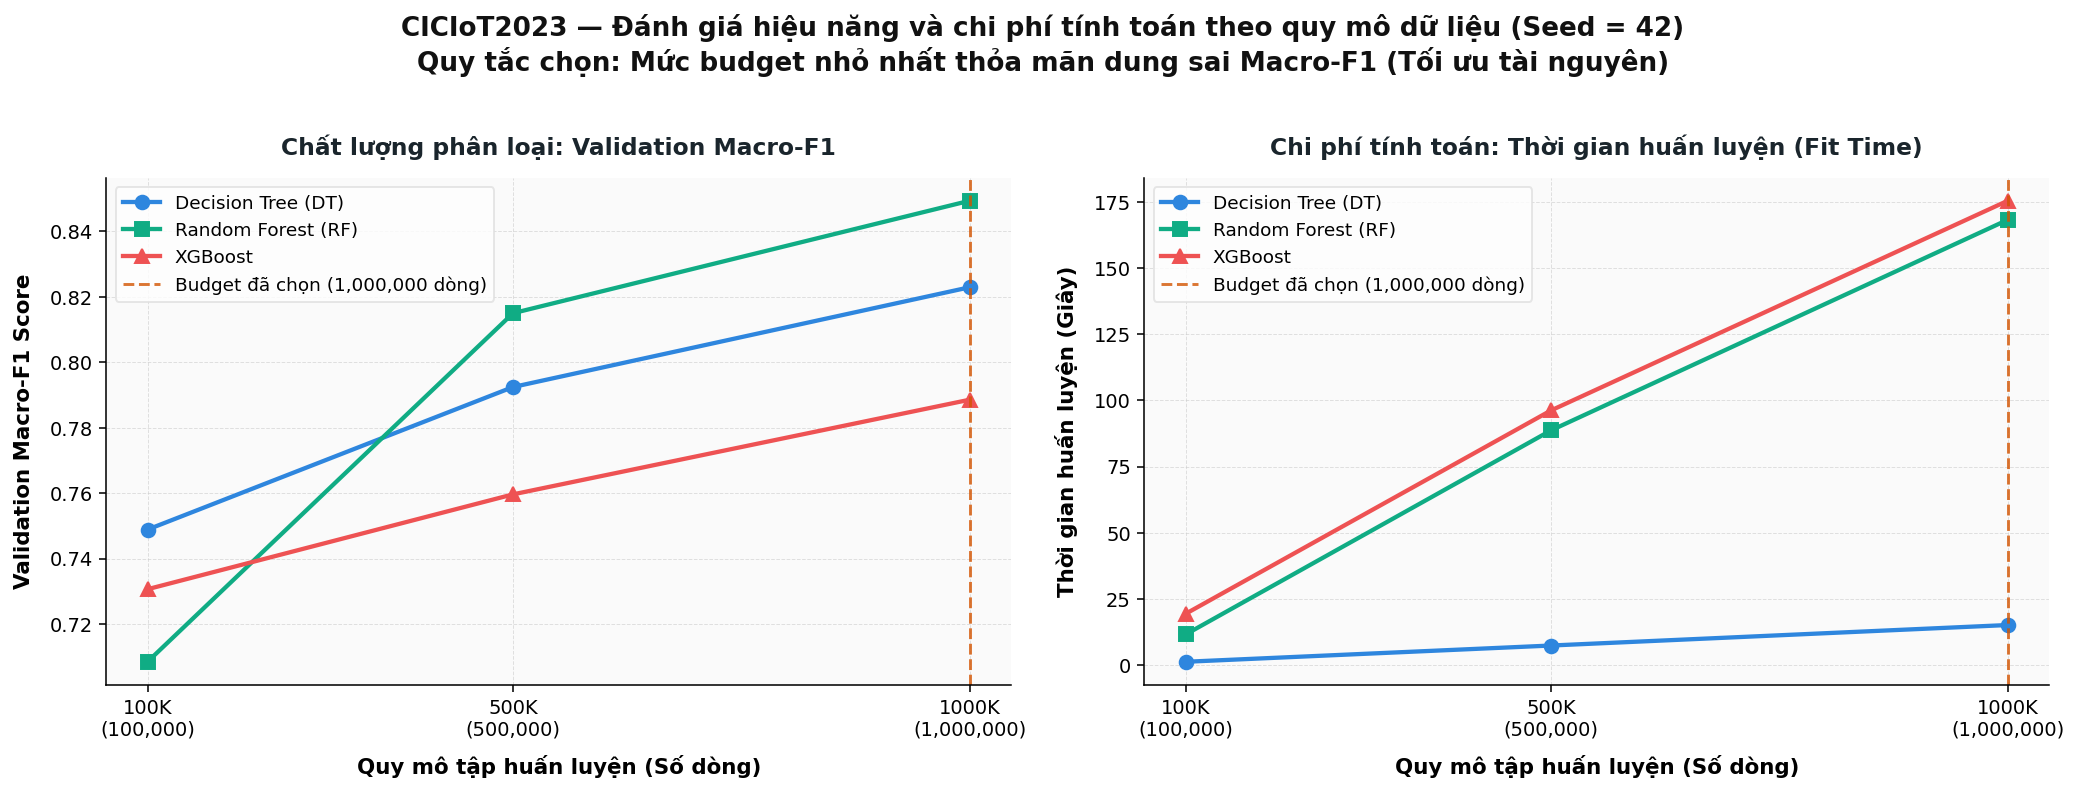

,budget,mean_macro_f1,mean_recall_BruteForce,mean_recall_Web_Based,total_fit_seconds,max_fit_peak_rss_mib
0,100000,0.729308,0.743682,0.915605,32.334198,927.843750
1,500000,0.788998,0.661853,0.742038,192.326965,1333.703125
2,1000000,0.820271,0.571600,0.565287,358.781768,1682.375000


Budget được chọn: 1000000


In [15]:
size_summary=BASELINE.groupby('budget',as_index=False).agg(
    mean_macro_f1=('macro_f1','mean'),mean_recall_BruteForce=('recall_BruteForce','mean'),
    mean_recall_Web_Based=('recall_Web_Based','mean'),total_fit_seconds=('fit_seconds','sum'),
    max_fit_peak_rss_mib=('fit_peak_rss_mib','max'))
reference=size_summary.sort_values(['mean_macro_f1','budget'],ascending=[False,True]).iloc[0]
eligible=size_summary[
    (size_summary.mean_macro_f1>=reference.mean_macro_f1-MACRO_TOLERANCE)&
    (size_summary.mean_recall_BruteForce>=reference.mean_recall_BruteForce-RARE_RECALL_TOLERANCE)&
    (size_summary.mean_recall_Web_Based>=reference.mean_recall_Web_Based-RARE_RECALL_TOLERANCE)]
CHOSEN_BUDGET=int(eligible.budget.min())
choice=dict(chosen_budget=CHOSEN_BUDGET,reference_budget=int(reference.budget),
    macro_tolerance=MACRO_TOLERANCE,rare_recall_tolerance=RARE_RECALL_TOLERANCE,
    rule='smallest eligible budget; compare mean metrics of 3 unweighted models; no test',
    protocol_hash=PROTOCOL_HASH)
choice_path=OUT/'budget_selection.json'
if choice_path.exists(): assert read_json(choice_path)==choice
else: write_json(choice_path,choice)
size_summary.to_csv(OUT/'budget_summary.csv',index=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=140)

# Cấu hình màu sắc và ký hiệu riêng biệt cho 3 mô hình
model_styles = {
    'DT': {'color': '#2E86DE', 'marker': 'o', 'name': 'Decision Tree (DT)'},
    'RF': {'color': '#10AC84', 'marker': 's', 'name': 'Random Forest (RF)'},
    'XGBoost': {'color': '#EE5253', 'marker': '^', 'name': 'XGBoost'}
}

for name in MODELS:
    part = BASELINE[BASELINE.model == name].sort_values('budget')
    style = model_styles.get(name, {'color': '#333333', 'marker': 'o', 'name': name})
    
    # Subplot 1: Macro-F1
    axes[0].plot(
        part.budget, part.macro_f1,
        marker=style['marker'], markersize=7, linewidth=2.2,
        color=style['color'], label=style['name']
    )
    # Subplot 2: Fit time
    axes[1].plot(
        part.budget, part.fit_seconds,
        marker=style['marker'], markersize=7, linewidth=2.2,
        color=style['color'], label=style['name']
    )

# Highlight mức ngân sách được lựa chọn
for ax in axes:
    ax.axvline(
        CHOSEN_BUDGET, color='#D35400', linestyle='--', linewidth=1.5, alpha=0.8,
        label=f'Budget đã chọn ({CHOSEN_BUDGET:,} dòng)'
    )
    ax.set_xticks(BUDGETS)
    ax.set_xticklabels([f"{b//1000}K\n({b:,})" for b in BUDGETS], fontsize=10, fontweight='medium')
    ax.set_xlabel('Quy mô tập huấn luyện (Số dòng)', fontsize=11, fontweight='bold', labelpad=8)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6, color='#CCCCCC')
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=True, facecolor='white', edgecolor='#E0E0E0', fontsize=9.5)

axes[0].set_ylabel('Validation Macro-F1 Score', fontsize=11, fontweight='bold', labelpad=8)
axes[0].set_title('Chất lượng phân loại: Validation Macro-F1', fontsize=12, fontweight='bold', pad=12, color='#1A252C')

axes[1].set_ylabel('Thời gian huấn luyện (Giây)', fontsize=11, fontweight='bold', labelpad=8)
axes[1].set_title('Chi phí tính toán: Thời gian huấn luyện (Fit Time)', fontsize=12, fontweight='bold', pad=12, color='#1A252C')

fig.suptitle(
    f"CICIoT2023 — Đánh giá hiệu năng và chi phí tính toán theo quy mô dữ liệu (Seed = {SEED})\n"
    f"Quy tắc chọn: Mức budget nhỏ nhất thỏa mãn dung sai Macro-F1 (Tối ưu tài nguyên)",
    fontsize=13.5, fontweight="bold", y=1.02, color="#111111"
)

fig.tight_layout()
fig.savefig(OUT / 'budget_comparison.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)
display(size_summary)
print('Budget được chọn:', CHOSEN_BUDGET)


## 6. Giai đoạn B — trọng số sqrt và balanced trên budget chung
Với số mẫu lớp c là n_c và tổng N: `w_c=(N/(8*n_c))**alpha`, alpha=0/0,5/1. Sau đó chuẩn hóa trung bình trọng số mẫu bằng 1. Baseline none của budget đã chọn được dùng lại, không huấn luyện lại. Không bật thêm `class_weight` hoặc `scale_pos_weight` để tránh nhân trọng số hai lần.

In [16]:
for mode in ['sqrt','balanced']:
    for name in MODELS:
        run_experiment(name,CHOSEN_BUDGET,mode)
        results_frame().to_csv(OUT/'validation_results.csv',index=False)
ALL_RESULTS=results_frame()
WEIGHT_RESULTS=ALL_RESULTS[ALL_RESULTS.budget==CHOSEN_BUDGET].copy()
assert len(WEIGHT_RESULTS)==9
WEIGHT_RESULTS.to_csv(OUT/'weight_comparison.csv',index=False)
display(WEIGHT_RESULTS[['model','weight_mode','macro_precision','macro_recall','macro_f1','rare_mean_f1',
    'recall_BruteForce','recall_Web_Based','fit_seconds','predict_proba_seconds']].sort_values(['model','macro_f1'],ascending=[True,False]))

Training: DT_n1000000_sqrt_s42
DT_n1000000_sqrt_s42 macro-F1= 0.79159 fit seconds= 15.29
Training: RF_n1000000_sqrt_s42
RF_n1000000_sqrt_s42 macro-F1= 0.83678 fit seconds= 167.49
Training: XGBoost_n1000000_sqrt_s42
XGBoost_n1000000_sqrt_s42 macro-F1= 0.82132 fit seconds= 173.54
Training: DT_n1000000_balanced_s42
DT_n1000000_balanced_s42 macro-F1= 0.75769 fit seconds= 12.7
Training: RF_n1000000_balanced_s42
RF_n1000000_balanced_s42 macro-F1= 0.79435 fit seconds= 168.28
Training: XGBoost_n1000000_balanced_s42
XGBoost_n1000000_balanced_s42 macro-F1= 0.8121 fit seconds= 183.6


,model,weight_mode,macro_precision,macro_recall,macro_f1,rare_mean_f1,recall_BruteForce,recall_Web_Based,fit_seconds,predict_proba_seconds
6,DT,none,0.805195,0.860159,0.822913,0.477666,0.628159,0.676752,15.189523,0.062530
9,DT,sqrt,0.769255,0.878046,0.791590,0.361621,0.722022,0.753185,15.289663,0.061686
12,DT,balanced,0.752071,0.884244,0.757695,0.237991,0.750903,0.871019,12.698318,0.061764
7,RF,none,0.878859,0.833280,0.849351,0.584002,0.566787,0.536624,168.201138,6.092173
10,RF,sqrt,0.833550,0.859793,0.836778,0.529211,0.631769,0.676752,167.494058,6.145784
13,RF,balanced,0.773714,0.871183,0.794351,0.380130,0.671480,0.764331,168.283730,6.520011
11,XGBoost,sqrt,0.799528,0.880487,0.821321,0.455003,0.696751,0.746815,173.542132,18.340768
14,XGBoost,balanced,0.786750,0.900263,0.812103,0.410883,0.743682,0.843949,183.597953,18.759080
8,XGBoost,none,0.781000,0.813036,0.788548,0.370681,0.519856,0.482484,175.391106,18.041450


## 7. Đóng băng ba cấu hình và model demo bằng validation
Chọn một phiên bản cho mỗi thuật toán trên cùng budget. Thứ tự: macro-F1 cao nhất → rare mean F1 cao nhất → fit nhanh hơn → experiment ID. Chọn model demo từ ba phiên bản này bằng cùng quy tắc. Test chỉ dùng để báo cáo ba model đã chọn; **không chọn lại theo test**.

In [17]:
ranked=WEIGHT_RESULTS.sort_values(['macro_f1','rare_mean_f1','fit_seconds','experiment_id'],ascending=[False,False,True,True])
chosen=ranked.drop_duplicates('model').copy()
assert set(chosen.model)==set(MODELS)
winner_ids=chosen.experiment_id.tolist()
frozen_models=[]
for key in winner_ids:
    d=OUT/'experiments'/key;r=RESULTS[key]
    frozen_models.append(dict(model=r['model'],experiment_id=key,budget=r['budget'],weight_mode=r['weight_mode'],
        model_sha256=sha256(d/'model.joblib'),config_sha256=sha256(d/'config.json'),
        validation_macro_f1=r['validation']['macro_f1']))
frozen_core=dict(protocol_hash=PROTOCOL_HASH,chosen_budget=CHOSEN_BUDGET,
    models=frozen_models,demo_experiment_id=winner_ids[0],selection_split='val',test_used_for_selection=False)
frozen_path=OUT/'frozen_selection.json'
if frozen_path.exists():
    FROZEN=read_json(frozen_path)
    assert all(FROZEN[k]==v for k,v in frozen_core.items()), 'Không được thay đổi lựa chọn đã đóng băng.'
else:
    FROZEN=dict(**frozen_core,frozen_at=now());write_json(frozen_path,FROZEN)
chosen.to_csv(OUT/'selected_validation_results.csv',index=False)
print('Đã khóa model trước khi mở test:',winner_ids)
print('Model demo được chọn bằng validation:',FROZEN['demo_experiment_id'])

Đã khóa model trước khi mở test: ['RF_n1000000_none_s42', 'DT_n1000000_none_s42', 'XGBoost_n1000000_sqrt_s42']
Model demo được chọn bằng validation: RF_n1000000_none_s42


## 8. Xuất pipeline từ CSV cho Hải/Kiên và kiểm tra lưu/nạp
Tái dựng **imputer hằng** bằng median đã lưu của source train, chọn đúng 44 cột; không tính lại median từ pilot/validation/test. Pipeline chuẩn sklearn ghép imputer này với model; không cần custom class để nạp joblib. Với CSV, helper chuyển numeric, Inf→NaN, rồi pipeline điền thiếu. Cột nhãn/metadata bị bỏ qua bởi allowlist. Không tự sửa chính tả `Magnitue`.

Kiểm tra dưới đây xác nhận phép biến đổi hằng và pipeline trên các vector đã xử lý; kiểm chứng end-to-end từ CSV gốc của một phiên độc lập vẫn là bước nghiệm thu riêng.

In [18]:
from sklearn.preprocessing import FunctionTransformer
BUNDLES=OUT/'handoff';BUNDLES.mkdir(exist_ok=True)

def fixed_tree_transformer():
    medians=SOURCE_CONFIG['imputation']['medians']
    transformers=[(f'feature_{i:02d}',SimpleImputer(strategy='constant',fill_value=float(medians[f]),keep_empty_features=True),[f])
                  for i,f in enumerate(FEATURES)]
    transform=ColumnTransformer(transformers,remainder='drop',n_jobs=1,verbose_feature_names_out=False)
    # Fit only initializes schema for constant imputers. Values are source-train medians, not re-estimated.
    transform.fit(pd.DataFrame([{f:float(medians[f]) for f in FEATURES}]))
    return transform

for entry in FROZEN['models']:
    key=entry['experiment_id'];source=OUT/'experiments'/key;target=BUNDLES/entry['model']
    target.mkdir(exist_ok=True)
    assert sha256(source/'model.joblib')==entry['model_sha256']
    model=joblib.load(source/'model.joblib')
    pre=fixed_tree_transformer()
    cast=FunctionTransformer(np.asarray,kw_args={'dtype':np.float32},validate=False)
    pipeline=Pipeline([('preprocessing',pre),('float32',cast),('model',model)])
    golden=np.load(source/'golden_samples.npz',allow_pickle=False)
    frame=pd.DataFrame(golden['X_raw_float32'].astype(np.float64),columns=FEATURES)
    expected=golden['probabilities']
    assert np.allclose(pipeline.predict_proba(frame),expected,atol=1e-7,rtol=1e-6)
    probe=frame.iloc[:1].copy();probe.loc[:,FEATURES]=np.nan
    assert np.allclose(pre.transform(probe)[0],[SOURCE_CONFIG['imputation']['medians'][f] for f in FEATURES])
    joblib.dump(pipeline,target/'pipeline.joblib',compress=3)
    del pipeline,model,pre;gc.collect()
    loaded=joblib.load(target/'pipeline.joblib')
    assert np.allclose(loaded.predict_proba(frame),expected,atol=1e-7,rtol=1e-6)
    shutil.copy2(source/'model.joblib',target/'model.joblib')
    if (source/'model.ubj').exists(): shutil.copy2(source/'model.ubj',target/'model.ubj')
    for name in ['config.json','golden_samples.npz']: shutil.copy2(source/name,target/name)
    for name in ['feature_schema.json','preprocessing_config.json','label_mapping.json']:
        shutil.copy2(SOURCE/name,target/name)
    frame.to_csv(target/'example_processed_features.csv',index=False)
    write_json(target/'bundle_metadata.json',dict(**entry,run_id=RUN_ID,versions=VERSIONS,
        pipeline_sha256=sha256(target/'pipeline.joblib'),class_order=CLASS_NAMES,
        input_features_required=FEATURES,extra_columns='ignored; labels never used as features',
        fit_scope='fixed medians from full source train; no refit of statistics',
        golden_check=True,example_csv='processed values, not original raw CSV capture'))
    del loaded,frame;golden.close();gc.collect()


In [19]:
INFERENCE_HELPER = '"""Inference helper: load only your own trusted bundle. Match requirements_runtime.txt."""\nfrom pathlib import Path\nimport json\nimport joblib\nimport numpy as np\nimport pandas as pd\n\ndef load_bundle(bundle_dir):\n    root=Path(bundle_dir)\n    metadata=json.loads((root/\'bundle_metadata.json\').read_text())\n    return joblib.load(root/\'pipeline.joblib\'),metadata\n\ndef predict_frame(pipeline,metadata,frame):\n    required=metadata[\'input_features_required\']\n    if frame.columns.duplicated().any(): raise ValueError(\'Duplicate column names\')\n    missing=sorted(set(required)-set(frame.columns))\n    if missing: raise ValueError(f\'Missing columns: {missing}\')\n    numeric=frame.loc[:,required].apply(pd.to_numeric,errors=\'raise\').astype(np.float64)\n    numeric=numeric.replace([np.inf,-np.inf],np.nan)\n    probability=pipeline.predict_proba(numeric)\n    if not np.isfinite(probability).all(): raise ValueError(\'Invalid probabilities\')\n    labels=probability.argmax(axis=1)\n    out=pd.DataFrame({\'input_row_index\':np.arange(len(frame)),\n                      \'predicted_class_id\':labels,\n                      \'predicted_class_name\':[metadata[\'class_order\'][int(i)] for i in labels]})\n    for i,c in enumerate(metadata[\'class_order\']): out[\'probability_\'+c]=probability[:,i]\n    return out\n\ndef predict_csv(bundle_dir,csv_path,output_path,chunksize=25000):\n    pipeline,metadata=load_bundle(bundle_dir)\n    offset=0\n    for i,chunk in enumerate(pd.read_csv(csv_path,chunksize=chunksize)):\n        result=predict_frame(pipeline,metadata,chunk)\n        result[\'input_row_index\']+=offset;offset+=len(chunk)\n        result.to_csv(output_path,index=False,mode=\'w\' if i==0 else \'a\',header=i==0)\n    return offset\n'
(OUT/'predict_csv.py').write_text(INFERENCE_HELPER,encoding='utf-8')
# Import the exported helper and validate it against golden model probabilities on Kaggle.
import importlib.util
spec=importlib.util.spec_from_file_location('datn_predict',OUT/'predict_csv.py')
helper_module=importlib.util.module_from_spec(spec);spec.loader.exec_module(helper_module)
for entry in FROZEN['models']:
    folder=BUNDLES/entry['model'];pipeline,metadata=helper_module.load_bundle(folder)
    frame=pd.read_csv(folder/'example_processed_features.csv',float_precision='round_trip')
    frame['label']='ignored_metadata'
    actual=helper_module.predict_frame(pipeline,metadata,frame)
    golden=np.load(folder/'golden_samples.npz',allow_pickle=False)
    assert np.allclose(actual[['probability_'+c for c in CLASS_NAMES]].to_numpy(),golden['probabilities'],atol=1e-7,rtol=1e-6)
    try: helper_module.predict_frame(pipeline,metadata,frame.drop(columns=FEATURES[0]))
    except ValueError: pass
    else: raise AssertionError('Missing feature not rejected')
    golden.close();del pipeline;gc.collect()
print('Đã xuất và kiểm tra pipeline + helper CSV cho DT/RF/XGBoost.')


Đã xuất và kiểm tra pipeline + helper CSV cho DT/RF/XGBoost.


## 9. Đánh giá test sau khi đã đóng băng
`RUN_FINAL_TEST=True` thực hiện bước này trong Run All. False chỉ tạo bộ kết quả validation/pipeline, chưa hoàn thành bảng test. Mỗi model test được lưu và khóa riêng để resume; một marker ghi thời điểm bắt đầu xem test được giữ cả khi bị lỗi. Không thay model/config sau bước này. Ba mô hình không được xếp chọn lại theo điểm test.

In [20]:
TEST_RESULTS=[]
if RUN_FINAL_TEST:
    assert object_hash(read_json(OUT/'protocol.json'))==PROTOCOL_HASH
    assert read_json(frozen_path)==FROZEN
    test_marker=OUT/'test_started.json'
    if not test_marker.exists(): write_json(test_marker,dict(at=now(),frozen_sha256=sha256(frozen_path),purpose='final reporting only'))
    assert read_json(test_marker)['frozen_sha256']==sha256(frozen_path)
    XTEST,YTEST,TEST_IDS=open_evaluation('test')
    XTEST,YTEST,TEST_IDS,TEST_FLOAT32_HASHES=purge_evaluation(
        'test',XTEST,YTEST,TEST_IDS,TRAIN_FLOAT32_HASHES,VAL_FLOAT32_HASHES)
    for entry in FROZEN['models']:
        key=entry['experiment_id'];dest=OUT/'test'/key;report_path=dest/'result.json'
        source=OUT/'experiments'/key
        assert sha256(source/'model.joblib')==entry['model_sha256']
        assert sha256(source/'config.json')==entry['config_sha256']
        if report_path.exists():
            report=read_json(report_path)
            assert report['frozen_sha256']==sha256(frozen_path)
            for rel,digest in report['artifact_hashes'].items(): assert sha256(safe_file(dest,rel))==digest
            print('Resume test:',key)
        else:
            dest.mkdir(parents=True,exist_ok=True)
            model=joblib.load(source/'model.joblib')
            with RAMMonitor() as mem: scores=evaluate(model,XTEST,YTEST,TEST_IDS,dest,'test')
            report=dict(experiment_id=key,model=entry['model'],budget=entry['budget'],weight_mode=entry['weight_mode'],
                frozen_sha256=sha256(frozen_path),metrics=scores,eval_peak_rss_mib=mem.peak/2**20,status='complete')
            report['artifact_hashes']={str(p.relative_to(dest)):sha256(p) for p in sorted(dest.rglob('*')) if p.is_file() and p.name!='result.json'}
            write_json(report_path,report);del model;gc.collect()
        TEST_RESULTS.append(dict(model=entry['model'],experiment_id=key,budget=entry['budget'],weight_mode=entry['weight_mode'],
            fit_seconds=RESULTS[key]['fit_seconds'],fit_peak_rss_mib=RESULTS[key]['fit_peak_rss_mib'],
            **{k:v for k,v in report['metrics'].items() if isinstance(v,(str,int,float))}))
    pd.DataFrame(TEST_RESULTS).to_csv(OUT/'final_test_comparison.csv',index=False)
    display(pd.DataFrame(TEST_RESULTS)[['model','budget','weight_mode','macro_precision','macro_recall','macro_f1',
        'accuracy','weighted_f1','fit_seconds','predict_proba_seconds']])
    del XTEST,YTEST,TEST_IDS;gc.collect()
else:
    print('Đã dừng ở validation theo cấu hình. Test chưa được mở trong lần thực thi này.')


test: 830,443 -> 765,991 rows; removed 64,452 (7.76%)


,class_name,before,after,removed
0,Normal,26078,26078,0
1,BruteForce,297,297,0
2,DDoS,563437,500510,62927
3,DoS,164798,163862,936
4,Mirai,55270,54681,589
5,Recon,8319,8319,0
6,Spoofing,11650,11650,0
7,Web-Based,594,594,0


,model,budget,weight_mode,macro_precision,macro_recall,macro_f1,accuracy,weighted_f1,fit_seconds,predict_proba_seconds
0,RF,1000000,none,0.876266,0.830697,0.846049,0.993158,0.993043,168.201138,6.120279
1,DT,1000000,none,0.799163,0.852604,0.816503,0.992574,0.992679,15.189523,0.060626
2,XGBoost,1000000,sqrt,0.799782,0.878159,0.820401,0.993142,0.993471,173.542132,17.611918


## 10. Tổng hợp và bàn giao
`macro_precision`/`macro_recall` là trung bình không trọng số của 8 lớp; bảng từng lớp nằm trong mỗi thư mục đánh giá. `predict_proba_seconds` là tổng thời gian dự đoán toàn split theo batch, không phải latency một mẫu. Latency batch 1, throughput batch 1024 và p95 nằm trong `inference_benchmark.json`.

Khi chạy thành công, tải **toàn bộ thư mục run** (không chỉ plots) để kiểm tra và cập nhật checklist. Để tái lập từ CSV gốc, chạy notebook processing → pilot → notebook này theo cùng config/seed và source manifest. Notebook này không tự chạy lại hai bước dữ liệu đã hoàn tất.

In [21]:
all_class_tables=[];timing_tables=[]
for key,r in RESULTS.items():
    d=OUT/'experiments'/key/'validation'
    table=pd.read_csv(d/'per_class_metrics.csv');table['experiment_id']=key;table['model']=r['model']
    table['budget']=r['budget'];table['weight_mode']=r['weight_mode'];table['split']='val'
    all_class_tables.append(table)
    for record in read_json(d/'inference_benchmark.json'):
        timing_tables.append(dict(experiment_id=key,model=r['model'],split='val',**{k:v for k,v in record.items() if k!='times_seconds'}))
for entry in FROZEN['models']:
    d=OUT/'test'/entry['experiment_id']
    if (d/'result.json').exists():
        table=pd.read_csv(d/'per_class_metrics.csv');table['experiment_id']=entry['experiment_id'];table['model']=entry['model']
        table['budget']=entry['budget'];table['weight_mode']=entry['weight_mode'];table['split']='test';all_class_tables.append(table)
        for record in read_json(d/'inference_benchmark.json'):
            timing_tables.append(dict(experiment_id=entry['experiment_id'],model=entry['model'],split='test',**{k:v for k,v in record.items() if k!='times_seconds'}))
pd.concat(all_class_tables,ignore_index=True).to_csv(OUT/'all_per_class_metrics.csv',index=False)
pd.DataFrame(timing_tables).to_csv(OUT/'all_inference_benchmarks.csv',index=False)
results_frame().to_csv(OUT/'validation_results.csv',index=False)
completed_test=all((OUT/'test'/e['experiment_id']/'result.json').exists() for e in FROZEN['models'])
status='complete' if completed_test else 'validation_complete_test_pending'
HANDOFF=f"""# Bàn giao detection 8 lớp — {RUN_ID}

Nguồn processing: {EXPECTED_SOURCE}. Pilot: {EXPECTED_PILOT}. Budget: {CHOSEN_BUDGET}.
Trạng thái: {status}. Model demo chọn bằng validation: {FROZEN['demo_experiment_id']}.

## Kết quả cần đọc
- baseline_size_comparison.csv, budget_summary.csv, budget_selection.json: quy mô và lý do chọn.
- weight_comparison.csv, selected_validation_results.csv: lựa chọn trọng số/model bằng validation.
- val_float32_purge_audit.json / test_float32_purge_audit.json và *_float32_kept_processed_indices.npy: số dòng/lớp trước-sau, lý do loại và index tái tạo tập đánh giá.
- final_test_comparison.csv: chỉ tồn tại khi test hoàn tất; không dùng để chọn lại model.
- all_per_class_metrics.csv: precision/recall/F1/support đủ 8 lớp.
- all_inference_benchmarks.csv: thời gian warmed predict_proba, batch 1 và batch cố định.
- experiments/<id>/validation và test/<id>: confusion matrix PNG/CSV, report, probabilities.npy và predictions.csv.gz cùng thứ tự.
- fit_seconds và fit_peak_rss_mib: thời gian fit và peak RSS process, không phải riêng model hay VRAM.
- protocol.json, environment.json, requirements_runtime.txt, input_integrity.json và frozen_selection.json: cấu hình, nguồn và khóa lựa chọn.

## Hải — XAI
Nạp handoff/<DT|RF|XGBoost>/pipeline.joblib. Estimator nằm ở named_steps['model']; input estimator là 44 feature raw đã impute/chọn cột và cast float32. Khi dùng TreeExplainer cho estimator, đưa đúng ma trận này, không đưa 46 cột gốc hoặc nhánh scaled. Classes 0..7 theo label_mapping.json. Mẫu nền lấy từ train; lưu sample ID/run ID. predict_proba trả 8 cột theo thứ tự lớp; không coi raw SHAP margin là xác suất.

## Kiên — tích hợp
Dùng predict_csv.py và handoff/<model>/. Ví dụ:
```python
from predict_csv import predict_csv
predict_csv('handoff/RF', 'input.csv', 'predictions.csv')
```
Đặt đường dẫn theo thư mục thực. Giữ đúng chính tả Magnitue. 44 feature đầu ra là bắt buộc; cột dư/nhãn bị bỏ qua. Helper chuyển numeric, Inf sang NaN; pipeline điền median nguồn, không fit lại. model.joblib chỉ nhận feature đã xử lý, pipeline.joblib nhận DataFrame numeric theo schema. example_processed_features.csv chứa giá trị đã xử lý phục vụ smoke check, không phải bản trích CSV gốc.

## Tái lập
1. Tái tạo processing từ notebook ciciot2023-do-an-processing.ipynb và nguồn trong source_snapshot/source_manifest.json.
2. Tái tạo pilot từ notebook ciciot2023-do-an-pilot.ipynb, seed 42 và ba budget.
3. Chạy notebook ciciot2023-do-an-models.ipynb cùng protocol.json, phiên bản và phần cứng được ghi. Dùng source run ID/hash tương ứng; không đổi ID để giả làm cùng một run.
4. Đối chiếu support, hash input, class/feature order, metrics/dự đoán và golden_samples.npz. Sai khác số học giữa môi trường cần được ghi, không hứa bit-identical trên mọi máy.

## Giới hạn
Một seed; chưa tuning sâu, SHAP feature selection hoặc xác minh độc lập theo phiên/thiết bị. Preprocessing fit toàn train nguồn, dùng cố định cho pilot. Sampling thay tỷ lệ lớp; tăng budget không thêm mẫu hai lớp hiếm. Validation/test tiếp tục được purge theo raw float32, ưu tiên hợp của mọi pilot train → validation → test; đọc audit để lấy số dòng/support thực dùng, không dùng số nguồn thay cho số đánh giá. Tập đánh giá đổi theo quy tắc label-independent và dùng chung cho mọi model; không so trực tiếp điểm với paper dùng split hoặc test cân bằng khác. RSS lấy mẫu mỗi 0,1 giây có thể bỏ qua peak rất ngắn; benchmark không gồm CSV/XAI/UI.
Test đã được dùng thì không thay cấu hình theo điểm test; mọi cải tiến sau cần công bố việc đã xem test. Chưa có chứng cứ độc lập end-to-end từ raw CSV mới hoặc giao diện/XAI chạy thật chỉ từ notebook này.
"""
(OUT/'README_HANDOFF.md').write_text(HANDOFF,encoding='utf-8')
write_json(OUT/'completion_checklist.json',dict(
    data_sources_identified=True,input_hash_verification_enabled=VERIFY_INPUT_HASHES,
    baseline_experiments=len(BASELINE),weight_comparison_rows=len(WEIGHT_RESULTS),
    models_exported=MODELS,csv_helper_and_pipeline_golden_checks=True,
    validation_metrics_complete=True,test_metrics_complete=completed_test,
    float32_validation_purged=True,float32_test_purged=completed_test,
    feature_selection_done=False,multi_seed_done=False,independent_raw_pipeline_reproduction_done=False,
    xai_and_ui_done=False))
write_json(OUT/'run_status.json',dict(run_id=RUN_ID,status=status,finished_at=now(),
    protocol_hash=PROTOCOL_HASH,chosen_budget=CHOSEN_BUDGET,models=MODELS,
    demo_experiment_id=FROZEN['demo_experiment_id'],test_complete=completed_test))
# Hash all delivered files, excluding the checksum file itself.
write_json(OUT/'artifact_checksums.json',{str(p.relative_to(OUT)):sha256(p) for p in sorted(OUT.rglob('*'))
    if p.is_file() and p.name!='artifact_checksums.json'})
print('OUTPUT:',OUT)
print('STATUS:',status)
print('Tải toàn bộ run về để rà kết quả và tick các công việc có bằng chứng hoàn thành.')


OUTPUT: /kaggle/working/model_experiments/models_20261008_073827_d29a37c3
STATUS: complete
Tải toàn bộ run về để rà kết quả và tick các công việc có bằng chứng hoàn thành.


## Tài liệu API và hướng nghiên cứu

- [XGBoost: parameters](https://xgboost.readthedocs.io/en/stable/parameter.html), [XGBClassifier/sample_weight](https://xgboost.readthedocs.io/en/stable/python/python_api.html).
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).
- [TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).
- [Enhancing cybersecurity… (2025)](https://doi.org/10.1371/journal.pone.0317346): định hướng cải tiến chọn đặc trưng sau baseline; notebook này không tuyên bố tái lập SHAP-RFECV của bài báo.

Các cấu hình và ngưỡng chọn budget là thiết kế thực nghiệm của đồ án. Kết quả chỉ được xác nhận sau khi chạy thành công trên Kaggle và kiểm tra output.